
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/09_Lab_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

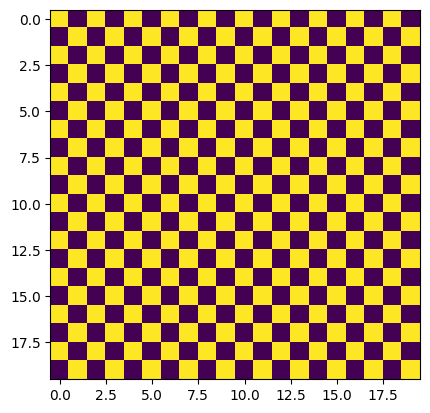

In [3]:
m, n = 20,20
h, v, d = patrones_balanceados(m, n)
plt.imshow(d)

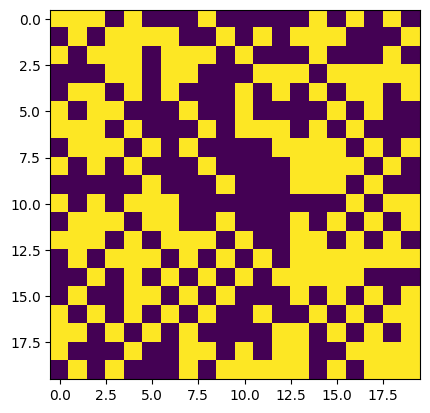

In [4]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (m, n)))

## Vamos a calcular la energía del patrón d y $w_{ij}$. Primero calculamos $w_{ij}$ y el campo $(w_{ij}*s_j)$

In [5]:
N = m*n
psi = np.concat(d).reshape(1,N)
psi[0]

array([ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1, -1,
        1, -1,  1, -1,  1

In [6]:
estado = d.flatten().reshape(N,1)

def pesos_ij(psi,N):
  w=np.zeros((N,N))
  for i in range(0, N):
    for j in range(0,N):
      if(i !=j):
        w[i,j] = psi[0][i]*psi[0][j]
  return w

psi = d.flatten().reshape(1,N)
w_ij = pesos_ij(psi,N)

In [7]:
w_ij

array([[ 0., -1.,  1., ...,  1., -1.,  1.],
       [-1.,  0., -1., ..., -1.,  1., -1.],
       [ 1., -1.,  0., ...,  1., -1.,  1.],
       ...,
       [ 1., -1.,  1., ...,  0., -1.,  1.],
       [-1.,  1., -1., ..., -1.,  0., -1.],
       [ 1., -1.,  1., ...,  1., -1.,  0.]])

In [8]:
def campo_local(w_ij, estado):
  campo = w_ij@estado
  return campo

def energiaTotal(estado, campo):
  return  -0.5*estado.T@campo


h = campo_local(w_ij, estado)
energiaTotal(estado, h)


array([[-79800.]])

In [9]:
ei = -0.5 * estado * h.reshape(N, 1)
E = np.sum(ei)
E

np.float64(-79800.0)

In [10]:
s_ruido = s_ruido.reshape(  N,1)
h = campo_local(w_ij, s_ruido)
energiaTotal(s_ruido, h)


array([[-19800.]])

In [11]:
for i in range (0,1200):
  h = campo_local(w_ij, s_ruido)
  index = np.random.randint(0, N)
  direccion =  np.sign(h[index])

  if(direccion>0):
    s_ruido[index] = 1
  else:
    s_ruido[index] = -1


h = campo_local(w_ij, s_ruido)
energiaTotal(s_ruido, h)




array([[-75072.]])

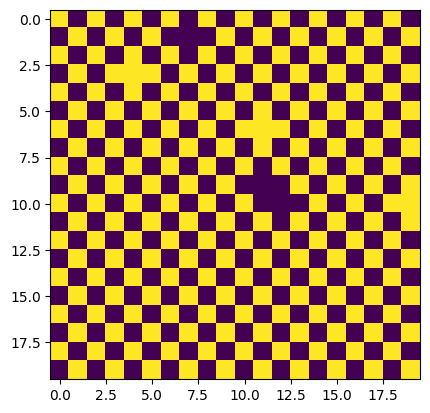

In [12]:
plt.imshow(np.reshape(s_ruido, (m, n)))

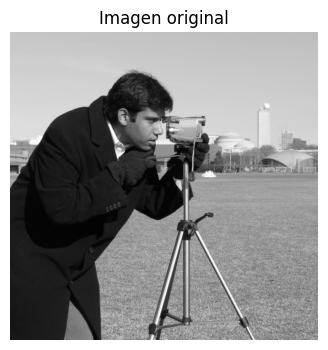

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

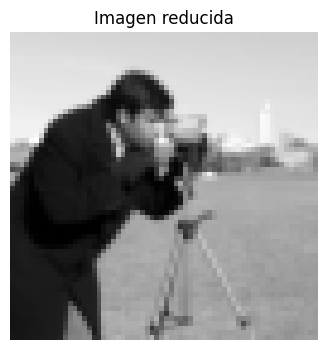

In [14]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

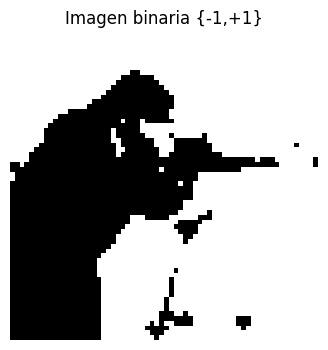

In [15]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [16]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

In [42]:
# ============================================================
# Ruido
# ============================================================

def agregar_ruido(s, frac=0.35, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido


frac_ruido = 0.35

s_ruido = agregar_ruido(np.concat(img_bin), frac=frac_ruido, seed=123)


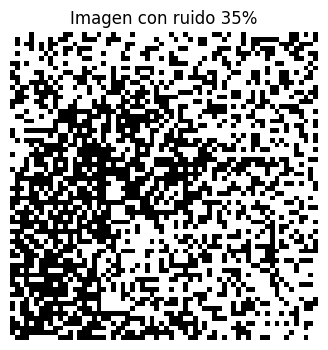

In [43]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

In [44]:
# 1. Definir parámetros y preparar patrón
N_pixels = n * m  # 64 * 64 = 4096
psi_camera = img_bin.flatten().reshape(1, N_pixels)

# 2. Calcular matriz de pesos usando la regla de Hebb de manera eficiente
# w_ij = (1/N) * sum_mu(xi_i * xi_j)
W_camera = (psi_camera.T @ psi_camera) / N_pixels
np.fill_diagonal(W_camera, 0)  # w_ii = 0
print("Matriz de pesos calculada con forma:", W_camera.shape)

Matriz de pesos calculada con forma: (4096, 4096)


In [45]:
# 3. Proceso de recuperación asincrónica aleatoria
# Aseguramos que s_ruido esté en el formato de vector correcto
s_recuperada = s_ruido.flatten().astype(float)

pasos_evaluacion = 150000  # Número de iteraciones para visitar suficientes píxeles

for step in range(pasos_evaluacion):
    # 1. Seleccionar un píxel/neurona de forma aleatoria
    idx = np.random.randint(0, N_pixels)

    # 2. Calcular el campo local que siente esa neurona i
    # h_i = sum_j w_ij * s_j
    campo_i = np.dot(W_camera[idx], s_recuperada)

    # 3. Actualizar el estado usando la regla s_i = sign(h_i)
    if campo_i != 0:
        s_recuperada[idx] = np.sign(campo_i)


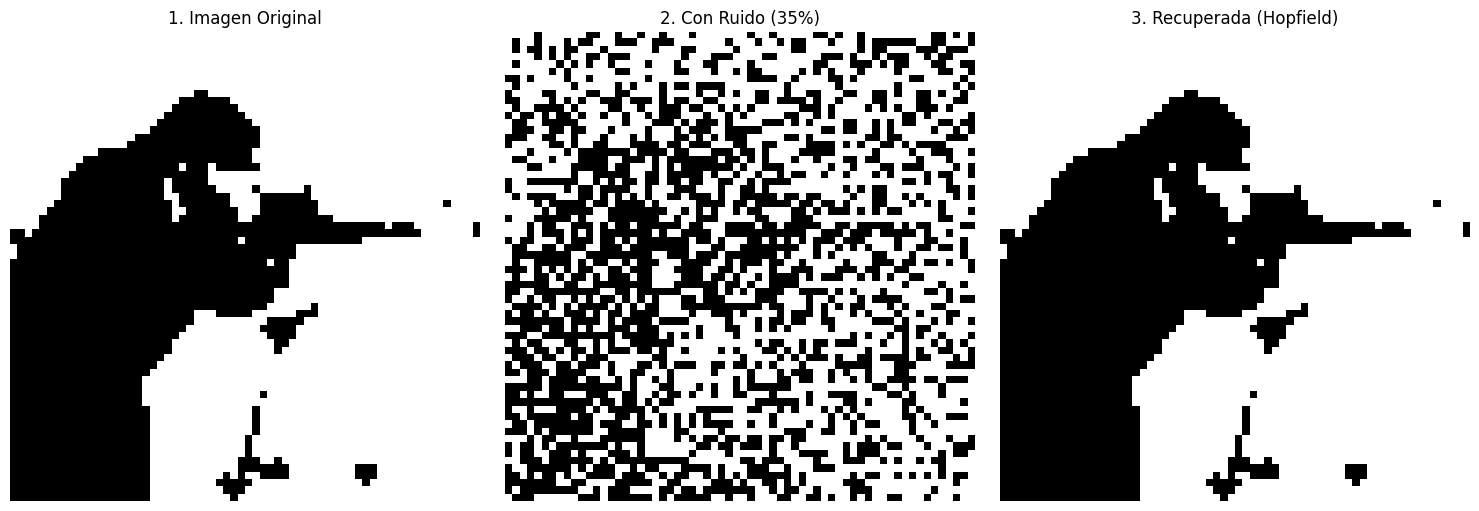

In [46]:
# 4. Visualizar los resultados
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Imagen original
axs[0].imshow(img_bin, cmap="gray")
axs[0].set_title("1. Imagen Original")
axs[0].axis("off")

# Imagen ruidosa de entrada
axs[1].imshow(s_ruido.reshape(n, m), cmap="gray")
axs[1].set_title(f"2. Con Ruido ({frac_ruido*100:.0f}%)")
axs[1].axis("off")

# Imagen recuperada final
axs[2].imshow(s_recuperada.reshape(n, m), cmap="gray")
axs[2].set_title("3. Recuperada (Hopfield)")
axs[2].axis("off")

plt.tight_layout()
plt.show()